## Gold Price Prediction using Linear Regression
Predicting Tomorrow's Gold Closing Price

Core strategy: Predict the daily price change (Close_tomorrow - Close_today) and reconstruct tomorrow's absolute closing price:

predicted_tomorrow_close = today_close + predicted_change

This design is more suitable for Linear Regression because predicting the daily price change helps reduce the effect of long-term price trends and makes the target variable more stable. As a result, the relationship between input features and the target becomes more linear, which better matches the assumptions of the Linear Regression model.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
df = pd.read_csv("../../data/Gold_Market_10y.csv")
df.head()

,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.949997,107.000000,106.260002,106.610001,8098700,106.949997,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.050003,108.150002,107.529999,107.540001,10471800,108.050003,1.028524,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.089996,108.180000,107.349998,107.919998,6656000,108.089996,0.037014,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.250000,109.580002,107.900002,107.910004,15785200,109.250000,1.073183,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.570000,110.699997,109.919998,110.449997,13213700,110.570000,1.208238,NaN,NaN,NaN,NaN,2016,2,3,1


## 3. Explore Dataset Structure

In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (2511, 16)

Columns:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20', 'Year', 'Month', 'Day_of_Week', 'Quarter']

Data types:
Date                 str
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Adj Close        float64
Daily_Return     float64
MA_20            float64
MA_50            float64
MA_200           float64
Volatility_20    float64
Year               int64
Month              int64
Day_of_Week        int64
Quarter            int64
dtype: object

Missing values:
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Adj Close          0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64


## 4. Convert Date and Sort Data

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df[["Date", "Close"]].head()

,Date,Close
0,2016-01-29,106.949997
1,2016-02-01,108.050003
2,2016-02-02,108.089996
3,2016-02-03,109.250000
4,2016-02-04,110.570000


## 5. Create Target Variable (Next-Day Close)

In [5]:
df["Target_Next_Close"] = df["Close"].shift(-1)
df[["Close", "Target_Next_Close"]].head()

,Close,Target_Next_Close
0,106.949997,108.050003
1,108.050003,108.089996
2,108.089996,109.250000
3,109.250000,110.570000
4,110.570000,112.320000


## 6. Feature Engineering

In [6]:
df["Close_lag_1"] = df["Close"].shift(1)
df["Close_lag_2"] = df["Close"].shift(2)
df["Close_lag_3"] = df["Close"].shift(3)

df["Volume_lag_1"] = df["Volume"].shift(1)
df["Return_lag_1"] = df["Daily_Return"].shift(1)

## 7. Select Features

In [7]:
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "MA_20",
    "MA_50",
    "Volatility_20",
    "Month",
    "Day_of_Week",
    "Quarter",
    "Close_lag_1",
    "Close_lag_2",
    "Close_lag_3",
    "Volume_lag_1",
    "Return_lag_1"
]

## 8. Clean Dataset

In [8]:
model_df = df[feature_columns + ["Target_Next_Close"]].dropna().copy()

print("Model dataset shape:", model_df.shape)
model_df.head()

Model dataset shape: (2461, 18)


,Open,High,Low,Close,Volume,Daily_Return,MA_20,MA_50,Volatility_20,Month,Day_of_Week,Quarter,Close_lag_1,Close_lag_2,Close_lag_3,Volume_lag_1,Return_lag_1,Target_Next_Close
49,119.470001,120.300003,119.419998,120.029999,9846000,1.351008,118.1205,116.9394,1.147330,4,0,2,118.430000,118.610001,116.940002,9078900.0,-0.151758,120.050003
50,120.230003,120.349998,119.550003,120.050003,9689500,0.016666,118.2295,117.2014,1.104504,4,1,2,120.029999,118.430000,118.610001,9846000.0,1.351008,118.769997
51,119.370003,119.430000,118.559998,118.769997,8841500,-1.066228,118.2700,117.4158,1.134788,4,2,2,120.050003,120.029999,118.430000,9689500.0,0.016666,117.110001
52,118.089996,118.190002,116.949997,117.110001,13165800,-1.397656,118.0960,117.5962,1.053423,4,3,2,118.769997,120.050003,120.029999,8841500.0,-1.066228,117.919998
53,117.330002,118.120003,117.190002,117.919998,7838100,0.691655,117.9855,117.7696,1.067764,4,4,2,117.110001,118.769997,120.050003,13165800.0,-1.397656,117.739998


## 9. Define X and y

In [9]:
X = model_df[feature_columns]
y = model_df["Target_Next_Close"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2461, 17)
y shape: (2461,)


## 10. Train-Test Split (Chronological)

In [10]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1968
Testing samples: 493


## 11. Build and Train Linear Regression Model

In [11]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


## 12. Make Predictions

In [12]:
train_predictions = linear_model.predict(X_train)
test_predictions = linear_model.predict(X_test)

## 13. Evaluate Model Performance

In [13]:
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training Metrics")
print("MAE :", round(train_mae, 4))
print("RMSE:", round(train_rmse, 4))
print("R²  :", round(train_r2, 4))

print("\nTesting Metrics")
print("MAE :", round(test_mae, 4))
print("RMSE:", round(test_rmse, 4))
print("R²  :", round(test_r2, 4))

Training Metrics
MAE : 0.9517
RMSE: 1.3451
R²  : 0.9973

Testing Metrics
MAE : 2.6042
RMSE: 3.7513
R²  : 0.9964


## 14. Compare Predictions

In [14]:
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_predictions
})

results_df["Error"] = results_df["Actual"] - results_df["Predicted"]
results_df.head(10)

,Actual,Predicted,Error
0,188.550003,187.734040,0.815963
1,188.500000,188.604617,-0.104617
2,188.330002,188.362176,-0.032174
3,187.600006,188.367998,-0.767992
4,187.110001,187.648929,-0.538929
5,184.529999,187.198601,-2.668602
6,184.419998,184.564387,-0.144389
7,185.660004,184.613464,1.046539
8,186.339996,185.674831,0.665165
9,187.470001,186.165422,1.304579


## 15. Visualize Results

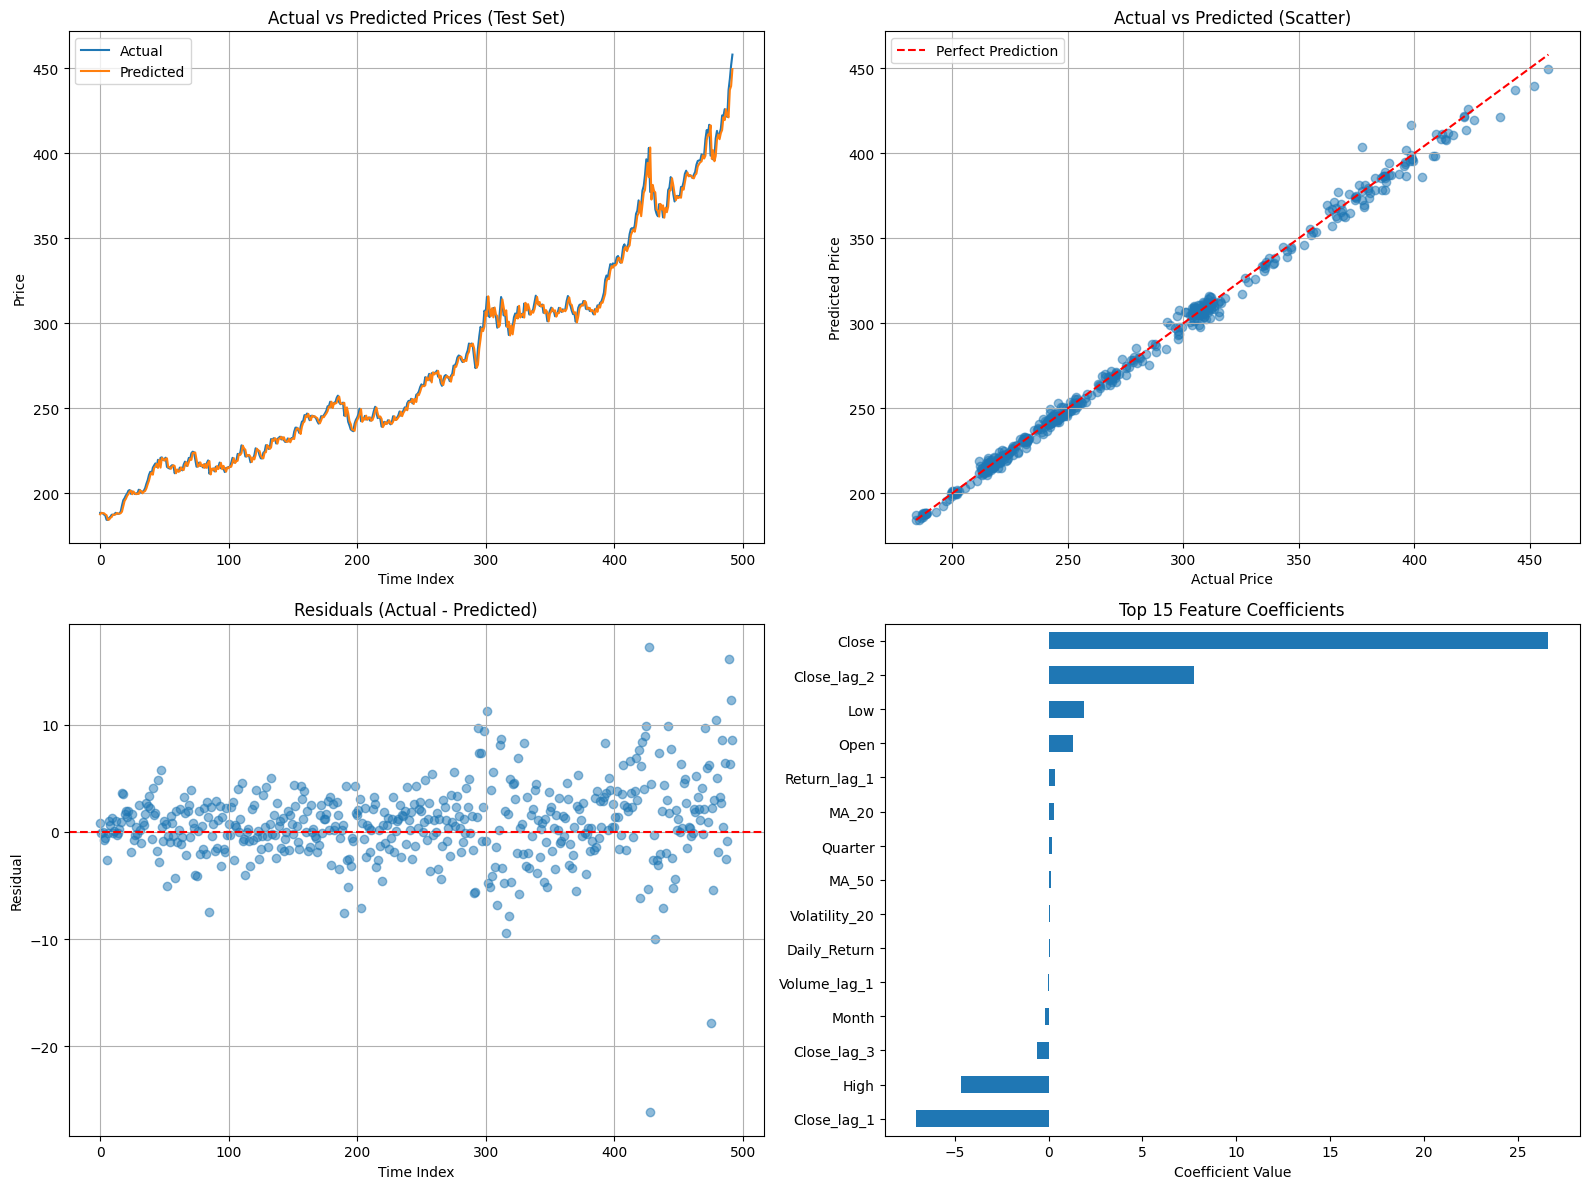

Visualization saved as linear_regression_results.png


In [ ]:
import os

# Residuals
residuals = y_test.values - test_predictions

# Get coefficients from pipeline
regressor = linear_model.named_steps["regressor"]

# Convert coefficients to dataframe
coefficients = pd.Series(regressor.coef_, index=feature_columns)
top_features = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(15)

# Create 2x2 plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Line Plot)
ax1 = axes[0, 0]
ax1.plot(range(len(y_test)), y_test.values, label='Actual', linewidth=1.5)
ax1.plot(range(len(test_predictions)), test_predictions, label='Predicted', linewidth=1.5)
ax1.set_title('Actual vs Predicted Prices (Test Set)')
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Price')
ax1.legend()
ax1.grid(True)

# 2. Scatter Plot
ax2 = axes[0, 1]
ax2.scatter(y_test.values, test_predictions, alpha=0.5)
min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
ax2.set_title('Actual vs Predicted (Scatter)')
ax2.set_xlabel('Actual Price')
ax2.set_ylabel('Predicted Price')
ax2.legend()
ax2.grid(True)

# 3. Residual Plot
ax3 = axes[1, 0]
ax3.scatter(range(len(residuals)), residuals, alpha=0.5)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_title('Residuals (Actual - Predicted)')
ax3.set_xlabel('Time Index')
ax3.set_ylabel('Residual')
ax3.grid(True)

# 4. Feature Coefficients (Top 15)
ax4 = axes[1, 1]
top_features.sort_values().plot(kind='barh', ax=ax4)
ax4.set_title('Top 15 Feature Coefficients')
ax4.set_xlabel('Coefficient Value')

plt.tight_layout()

# Create directory if it doesn't exist
os.makedirs("../../reports/figures/linear_regression", exist_ok=True)
plt.savefig("../../reports/figures/linear_regression/linear_regression_results.png", dpi=150)
plt.show()

print("Visualization saved to reports/figures/linear_regression/linear_regression_results.png")


## 16. Overfitting Check

In [16]:
print("Train R²:", round(train_r2, 4))
print("Test R² :", round(test_r2, 4))

if train_r2 - test_r2 > 0.10:
    print("Possible overfitting: training performance is noticeably better than testing performance.")
else:
    print("No strong overfitting signal based on train-test R² gap.")

Train R²: 0.9973
Test R² : 0.9964
No strong overfitting signal based on train-test R² gap.


## 17. Feature Importance

In [17]:
regressor = linear_model.named_steps["regressor"]

coefficients_df = pd.DataFrame({
    "Feature": feature_columns,
    "Coefficient": regressor.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coefficients_df

,Feature,Coefficient
3,Close,26.637884
13,Close_lag_2,7.721960
12,Close_lag_1,-7.063710
1,High,-4.651481
2,Low,1.893621
0,Open,1.287864
14,Close_lag_3,-0.640959
16,Return_lag_1,0.333605
6,MA_20,0.285170
9,Month,-0.183996


## 18. Save Results

In [ ]:
import os

# Create output directory if it doesn't exist
os.makedirs("../../outputs/linear_regression", exist_ok=True)

results_df.to_csv("../../outputs/linear_regression/test_predictions_linear_regression.csv", index=False)
coefficients_df.to_csv("../../outputs/linear_regression/linear_regression_coefficients.csv", index=False)

print("Results saved to:")
print("  - outputs/linear_regression/test_predictions_linear_regression.csv")
print("  - outputs/linear_regression/linear_regression_coefficients.csv")
